→ Gesynchroniseerde data geladen: SWITCH004 - preswitch
→ PES tijd: 43252.39s–44669.78s
→ EIT tijd: 43252.39s–44659.34s
→ Segment relatief: 270.00s–330.00s
→ Segment absoluut: 43522.39s–43582.39s


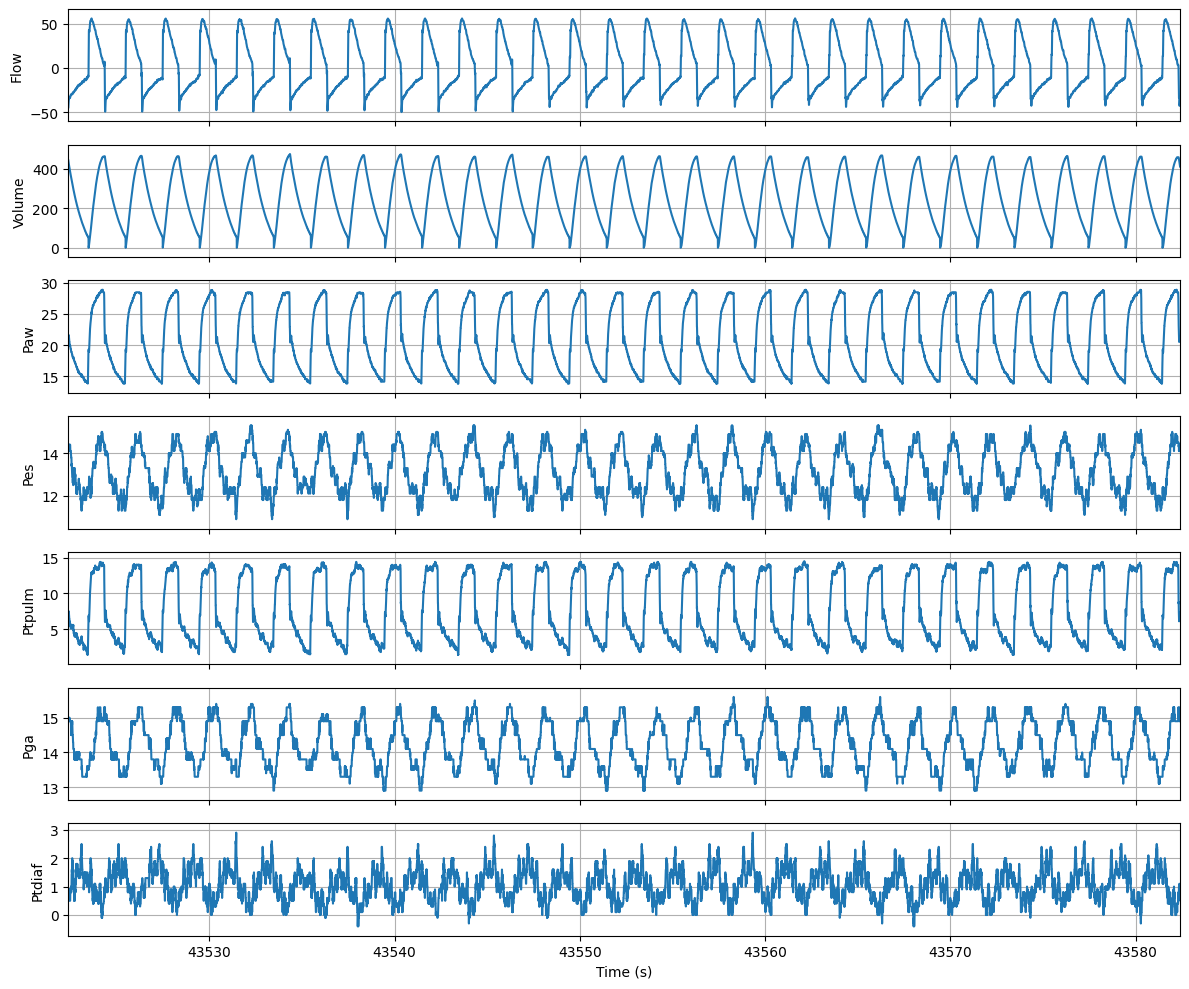

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append(r"../src")
sys.path.append(r"../config")

from loading import (
    load_synchronized_sequence,
    load_synchronized_eit,
)
from dataset_config import get_dataset_window


# ----------------
# Instellingen
# ----------------
patient = "004"
phase = "preswitch"

sync_path = ... # Path naar gesynchronizeerde data


# ---------------------------------------
# Helpers
# ---------------------------------------
def dynamic_ylim(signal, margin=0.1):
    signal = np.asarray(signal)

    if len(signal) == 0:
        return -1, 1

    y_min = np.min(signal)
    y_max = np.max(signal)
    y_range = y_max - y_min

    if y_range == 0:
        y_range = max(abs(y_min), 1.0)

    return y_min - margin * y_range, y_max + margin * y_range


# ---------------------------------------
# Gesynchroniseerde data inladen
# ---------------------------------------
sequence = load_synchronized_sequence(sync_path)

cd = sequence.continuous_data
eit_signal, eit_time = load_synchronized_eit(sequence)

time = cd["synchronized_pes"].time

flow = cd["synchronized_flow"].values
volume = cd["synchronized_volume"].values
paw = cd["synchronized_paw"].values
pes = cd["synchronized_pes"].values
ptpulm = cd["synchronized_ptpulm"].values
pga = cd["synchronized_pga"].values
ptdiaf = cd["synchronized_ptdiaf"].values

print(f"→ Gesynchroniseerde data geladen: SWITCH{patient} - {phase}")
print(f"→ PES tijd: {time[0]:.2f}s–{time[-1]:.2f}s")
print(f"→ EIT tijd: {eit_time[0]:.2f}s–{eit_time[-1]:.2f}s")


# -------------------------------
# Handmatig segment ophalen
# -------------------------------
t_start_rel, t_end_rel = get_dataset_window(patient, phase)

t_start = time[0] + t_start_rel
t_end = time[0] + t_end_rel

plot_mask = (time >= t_start) & (time <= t_end)

if not plot_mask.any():
    raise ValueError(
        f"Geen data gevonden tussen {t_start:.2f}s en {t_end:.2f}s"
    )

print(f"→ Segment relatief: {t_start_rel:.2f}s–{t_end_rel:.2f}s")
print(f"→ Segment absoluut: {t_start:.2f}s–{t_end:.2f}s")


# -------------------------------
# Plotten
# -------------------------------
signals = [
    ("Flow", flow),
    ("Volume", volume),
    ("Paw", paw),
    ("Pes", pes),
    ("Ptpulm", ptpulm),
    ("Pga", pga),
    ("Ptdiaf", ptdiaf),
]

fig, axs = plt.subplots(
    len(signals),
    1,
    figsize=(12, 10),
    sharex=True,
)

for ax, (label, signal) in zip(axs, signals):
    ax.plot(time, signal)
    ax.set_ylabel(label)
    ax.grid(True)

    ax.set_ylim(*dynamic_ylim(signal[plot_mask]))

axs[-1].set_xlabel("Time (s)")

plt.xlim(t_start, t_end)
plt.tight_layout()
plt.show()